# Perceptron & MLP



## Perceptron

* Implementing the single `Perceptron` Model class.
* Training the Perceptron model to solve on the `AND gate` using `gradient descent`. Reporting in the results, can it predict the correct outputs for each of the 4 input combinations?
* Further, training the Perceptron model to solve on the `XOR gate` using `gradient descent`. Report in the results.
* Finally, plotting the decision boundary for both trained Perceptron models.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, lr=0.5, n_epochs=5000, seed=0):
        self.lr = lr
        self.n_epochs = n_epochs
        self.rng = np.random.default_rng(seed)
        self.w = None
        self.b = None
        self.loss_history_ = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        z = X @ self.w + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_features = X.shape[1]
        self.w = self.rng.normal(0, 0.01, size=n_features)
        self.b = 0.0

        eps = 1e-12
        self.loss_history_.clear()

        for _ in range(self.n_epochs):
            p = self.predict_proba(X)

            # Binary cross-entropy loss
            loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
            self.loss_history_.append(loss)

            # Gradients for logistic regression
            dz = (p - y) / X.shape[0]
            dw = X.T @ dz
            db = dz.sum()

            # Gradient descent update
            self.w -= self.lr * dw
            self.b -= self.lr * db

        return self


In [ ]:
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = model.predict_proba(grid).reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, probs, levels=25, alpha=0.75)
    plt.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=80)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


In [ ]:
# Dataset for AND and XOR gates
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_AND = np.array([0, 0, 0, 1])  # AND gate
y_XOR = np.array([0, 1, 1, 0])  # XOR gate

Perceptron AND predictions: [0 0 0 1]
Perceptron AND accuracy: 1.0


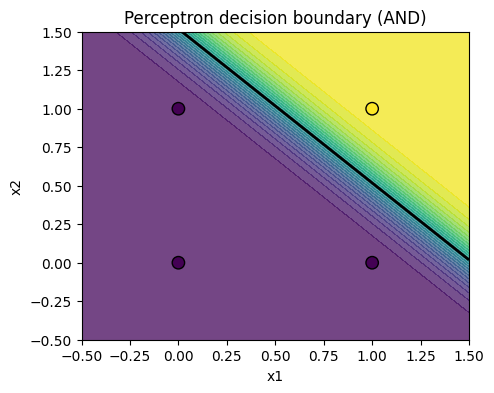

Perceptron XOR predictions: [1 1 1 1]
Perceptron XOR accuracy: 0.5


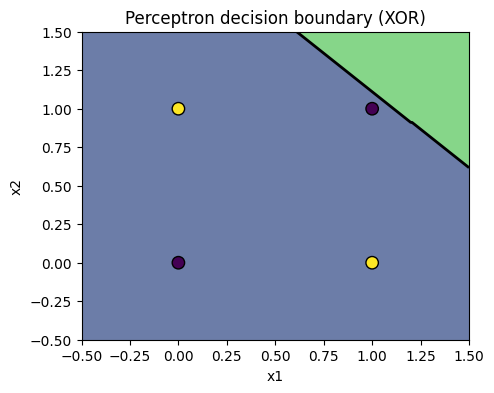

In [ ]:
# Train on AND
per_and = Perceptron(lr=0.5, n_epochs=5000, seed=1)
per_and.fit(X, y_AND)
pred_and = per_and.predict(X)
print("Perceptron AND predictions:", pred_and)
print("Perceptron AND accuracy:", (pred_and == y_AND).mean())

plot_decision_boundary(per_and, X, y_AND, title="Perceptron decision boundary (AND)")

# Train on XOR
per_xor = Perceptron(lr=0.5, n_epochs=5000, seed=1)
per_xor.fit(X, y_XOR)
pred_xor = per_xor.predict(X)
print("Perceptron XOR predictions:", pred_xor)
print("Perceptron XOR accuracy:", (pred_xor == y_XOR).mean())

plot_decision_boundary(per_xor, X, y_XOR, title="Perceptron decision boundary (XOR)")


## Multi-Layer Perceptron (MLP)

* Using the `PyTorch` framework to build a small MLP.
* Training the MLP on the `XOR gate` using `PyTorch`'s `autograd` functionality. Report on the result. Can the model solve the XOR problem? Test it for all 4 input combinations.
* Plotting the decision boundary of your trained MLP.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)  # logits
        return x

In [ ]:
def train(model, X, y, lr=0.05, n_epochs=3000, verbose=True):
    model.train()

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        logits = model(X_t)
        loss = criterion(logits, y_t)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if verbose and (epoch % 500 == 0 or epoch == n_epochs - 1):
            print(f"Epoch {epoch:4d} | loss = {loss.item():.6f}")

    return losses

def test(model, X, y, threshold=0.5):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        logits = model(X_t)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
        preds = (probs >= threshold).astype(int)

    print("X:", X)
    print("y true:", y.astype(int))
    print("y prob:", np.round(probs, 4))
    print("y pred:", preds)
    print("Accuracy:", (preds == y.astype(int)).mean())

    return preds, probs


Epoch    0 | loss = 0.699566
Epoch  500 | loss = 0.000493
Epoch 1000 | loss = 0.000166
Epoch 1500 | loss = 0.000083
Epoch 2000 | loss = 0.000049
Epoch 2500 | loss = 0.000032
Epoch 2999 | loss = 0.000022
X: [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y true: [0 1 1 0]
y prob: [0. 1. 1. 0.]
y pred: [0 1 1 0]
Accuracy: 1.0


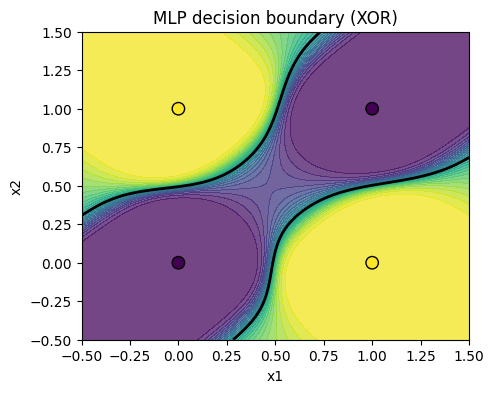

In [ ]:
# Train MLP on XOR
torch.manual_seed(0)
mlp = MLP(input_size=2, hidden_size=4, output_size=1)

losses = train(mlp, X, y_XOR, lr=0.05, n_epochs=3000, verbose=True)
preds, probs = test(mlp, X, y_XOR)

# Plot decision boundary for MLP
def plot_decision_boundary_mlp(model, X, y, title="MLP decision boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(grid_t)).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, probs, levels=25, alpha=0.75)
    plt.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=80)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary_mlp(mlp, X, y_XOR, title="MLP decision boundary (XOR)")
